In [78]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [2]:
plt.rc("xtick", labelsize = 15, top = False, bottom = False, direction = "in")   
plt.rc("ytick", labelsize = 15, left = False, right = False, direction = "in")
plt.rc("axes", grid = False, linewidth = 1.2, axisbelow = True)
plt.rc("grid", ls = "dotted", lw = 1)     
plt.rc("font", size = 30, family = "serif", serif = ["Computer Modern Serif"])
plt.rc("text", usetex = True)
plt.rc("figure", figsize = (12, 6), dpi = 72)
plt.rc("ytick.major", width = 1)
plt.rc("xtick.major", width = 1)
plt.rc("legend", fontsize = 15, framealpha = 0.5, edgecolor = "black", fancybox = True)

In [ ]:
def pointFinder(y, t, ofs=0, err=0.1, datpointserr=500):
    # Centrer signalet omkring 0 for nemmere beregning
    y_centered = y - ofs
    
    # Find alle steder hvor signalet skifter fortegn
    sign_changes = np.where(np.diff(np.sign(y_centered)) != 0)[0]
    
    dy = err
    
    intersects = []
    t1 = []
    
    if len(sign_changes) > 0:
        intersects.append(sign_changes[0])
        t1.append(t[sign_changes[0]])
        
        for idx in sign_changes[1:]:
            if idx - intersects[-1] > datpointserr: 
                intersects.append(idx)
                t1.append(t[idx])

    tops = []
    t2 = []
    for i in range(1, len(intersects)):
        start, end = intersects[i-1], intersects[i]
        interval_y = y[start:end]
        interval_t = t[start:end]
        
        if len(interval_y) == 0: 
            continue

        # Afgør om intervallet er en top eller en dal
        if np.mean(interval_y) > ofs:
            extreme_val = np.max(interval_y)
            # Find alle indekser, der har denne max-værdi
            all_indices = np.where(interval_y == extreme_val)[0]
        else:
            extreme_val = np.min(interval_y)
            # Find alle indekser, der har denne min-værdi
            all_indices = np.where(interval_y == extreme_val)[0]
            
        # Vælg det midterste indeks af plateauet (heltalsdivision giver midten)
        idx = all_indices[len(all_indices) // 2]
            
        tops.append(interval_y[idx])
        t2.append(interval_t[idx])
        
        if i == len(intersects)-1:
            interval_y = y[end:]
            interval_t = t[end:]
            if np.mean(interval_y) > ofs:
                extreme_val = np.max(interval_y)
                # Find alle indekser, der har denne max-værdi
                all_indices = np.where(interval_y == extreme_val)[0]
                idx = all_indices[len(all_indices) // 2]
                tops.append(interval_y[idx])
                t2.append(interval_t[idx])
            elif np.mean(interval_y) < ofs:
                extreme_val = np.min(interval_y)
                # Find alle indekser, der har denne min-værdi
                all_indices = np.where(interval_y == extreme_val)[0]
                idx = all_indices[len(all_indices) // 2]
                tops.append(interval_y[idx])
                t2.append(interval_t[idx])
            
     
    intersects = np.array(intersects)
    t1 = np.array(t1)
    tops = np.array(tops)
    t2 = np.array(t2)
    
    maske = (((tops) > (ofs + dy)) | ((tops) < (ofs - dy)))


    
    return intersects, t1, tops[maske], t2[maske]

In [ ]:
#Bølgelængde
l = 632.8e-9 #m

#Længde af rør
L = 6e-2 #m

#Atmosfærisk tryk defineres
p0 = 1 #atm
#Højden som målingerne er over men andre peaks er under 
peakheight = 5 #V

#Liste af n-værdier
ns = []

#Antal datasæt der skal gennemløbes
sets = 3

#Usikkerheder defineres
sigmaOmega = 1
sigmaL = 0.5e-3 #m
sigmap = 0.05 #atm

#Ophobningsloven som funktion defineres
sigma_eta = lambda n, Omega, L, p: np.sqrt(( (n / Omega) * sigmaOmega )**2 + ( (n / L) * sigmaL )**2 ( (1 / p0) * (n / (p / p0 - 1)) * sigmap )**2)

for i in range(sets):
    #Datasæt indlæses
    data = np.loadtxt(f"../Data/Day 1/Pump-000{i+1}.txt", skiprows=3)

    #Tryk for sættet defineres
    p = 2 #atm

    #Sættet splittes op i tid og spænding
    time = data[:,0]
    voltage = data[:,1]

    #Funktion der finder peaks og valleys bruges
    _, _, tops, times = pointFinder(voltage, time, ofs=np.mean(voltage), err=0.8)

    #Antallet af peaks over den givne højde findes
    Omega = len(tops[tops > peakheight])

    #eta findes
    eta = (Omega*l/L)/(p/p0 -1)

    #n findes
    n = 1+eta
    
    #Usikkerheden for eta i datasættet findes
    sigma = sigma_eta(.001, .001, .001)

    #n og usikkerhed tilføjes til liste
    ns.append(np.array([n, sigma]))
ns = np.array(ns)

In [ ]:
#Bølgelængde
l = 632.8e-9 #m

#Længde af rør
L = 6e-2 #m

#Atmosfærisk tryk defineres
p0 = 1 #atm

#Usikkerheder defineres
sigmaOmega = 1
sigmaL = 0.5e-3 #m
sigmap = 0.05 #atm

#Ophobningsloven som funktion defineres
sigma_eta = lambda n, Omega, L, p: np.sqrt(( (n / Omega) * sigmaOmega )**2 + ( (n / L) * sigmaL)**2 + ( (1 / p0) * (n / (p / p0 - 1)) * sigmap )**2)

def fracapprox(tops, times, time, p=2):
    """Assumes the continued data is directly proportional to the oscillation before"""
    avg = np.mean(tops)
    
    #Finder det hele antal bølgelængder
    if len(tops[tops >= avg]) >= len(tops)/2:
        #Højden som målingerne er over men andre peaks er under 
        peakheight = avg*1.2 #V
        
        #Antallet af peaks over den givne højde findes
        Omega = len(tops[tops > peakheight]) - 1
    else:
        #Højden som målingerne er under men andre peaks er over 
        peakheight = avg*0.8 #V
        
        #Antallet af peaks under den givne højde findes
        Omega = len(tops[tops < peakheight]) - 1

    #Tilføjer endestykket i starten
    start = np.where(time == times[0])[0][0]
    end = np.where(time == times[1])[0][0]
    wavelength = (time[end] - time[start])*2
    Omega += (time[start])/wavelength
    
    #Tilføjer endestykket i slutningen
    start = np.where(time == times[-2])[0][0]
    end = np.where(time == times[-1])[0][0]
    wavelength = (time[end] - time[start])*2
    Omega += (time[-1]-time[end])/wavelength

    print(Omega)
    #Eta findes
    eta = (Omega*l/L)/(p/p0 -1)

    #n findes
    n = 1+eta
    
    #Usikkerheden for eta i datasættet findes
    sigma = sigma_eta(eta, Omega, L, p)

    #n og usikkerhed retuneres
    return np.array([n, sigma])
def curveapprox():
    """Assumes that the data follows a chirp function with a frequence varience following ax^2 + bx + c"""
    
def zapprox(tops, p=2):
    """Assumes whole number of wavelengths"""
    avg = np.mean(tops)
    
    if len(tops[tops >= avg]) >= len(tops)/2:
        #Højden som målingerne er over men andre peaks er under 
        peakheight = avg*1.2 #V
        
        #Antallet af peaks over den givne højde findes
        Omega = len(tops[tops > peakheight]) - 1
    else:
        #Højden som målingerne er under men andre peaks er over 
        peakheight = avg*0.8 #V
        
        #Antallet af peaks under den givne højde findes
        Omega = len(tops[tops < peakheight]) - 1

    print(Omega)
    #Eta findes
    eta = (Omega*l/L)/(p/p0 -1)

    #n findes
    n = 1+eta
    
    #Usikkerheden for eta i datasættet findes
    sigma = sigma_eta(eta, Omega, L, p)

    #n og usikkerhed retuneres
    return np.array([n, sigma])

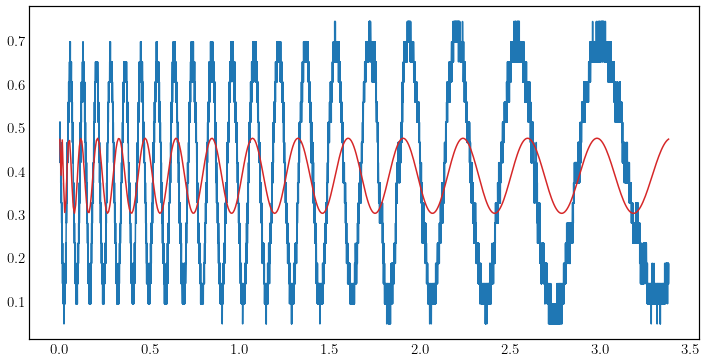

In [106]:
fig, ax = plt.subplots()
data = np.loadtxt(f"../Data/Day 2/Pump-000{1}.txt", skiprows=3)
#Sættet splittes op i tid og spænding
time = data[:,0]
voltage = data[:,1]
_, _, tops, times = pointFinder(voltage, time, ofs=np.mean(voltage), err=0.1)

#func = lambda t, A, a, b, c, phi: A*np.sin(a*t**2 + b*t + phi) + c
#coeffs, cov = curve_fit(func, time, voltage, [0.3, -9.5, 60, 4, 2])
func = lambda t, A, a, phi, b: A * np.sin(a * np.sqrt(t) + phi) + b
coeffs, cov = curve_fit(func, time, voltage, [0.3, -54, 1, .4])

ts = np.linspace(0, time[-1], 500)
A, a, phi, b = coeffs
ax.plot(time, voltage)
ax.plot(ts, func(ts, A, a, phi, b), color="C3")
#ax.plot(times, tops, "x", color="C3")

In [76]:
#Liste af n-værdier
ns = []

#Antal datasæt der skal gennemløbes
sets = 2

for i in range(sets):
    #Datasæt indlæses
    data = np.loadtxt(f"../Data/Day 2/Pump-000{i+1}.txt", skiprows=3)
    
    time = data[:,0]
    voltage = data[:,1]
    
    #Toppe og dale findes
    _, _, tops, times = pointFinder(voltage, time, ofs=np.mean(voltage), err=0.1)
    
    #Tryk for sættet defineres
    p = 2 #atm

    n, sigma = zapprox(tops, p)
    n, sigma = fracapprox(tops, times, time, p)
    
    #n og usikkerhed tilføjes til liste
    ns.append(np.array([n, sigma]))
ns = np.array(ns)

20
20.402992400351813
13
13.449822551880514


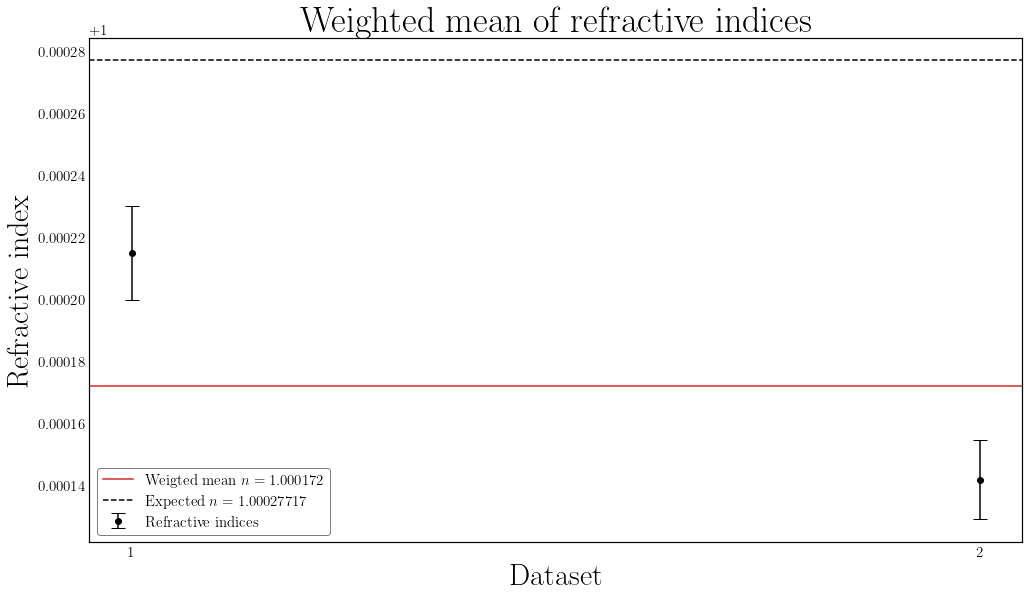

In [77]:
refIndecies = ns[:,0]
sigmas = ns[:,1]
navg = np.average(refIndecies, weights=1/sigmas**2)

fig, ax = plt.subplots(figsize=(15,9))

ax.errorbar(list(range(1, len(ns)+1)), refIndecies, fmt="o", color="black", yerr=sigmas, label="Refractive indices", capsize = 7)
ax.axhline(navg, color="C3", label=f"Weigted mean $n = {navg:.6f}$")
ax.axhline(1.00027717, color="black", linestyle="--", label=f"Expected $n = 1.00027717$")
ax.set_xticks(list(range(1, len(ns)+1)))
ax.set_xlabel("Dataset")
ax.set_ylabel("Refractive index")
ax.set_title("Weighted mean of refractive indices")
ax.legend()

fig.tight_layout()
